# Week 6 — Agents as Control Loops
### *Agents turn “one big prompt” into a loop of small, checkable steps.*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/agents_lecture.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---




## Learning objectives (by the end of this notebook, you can…)
- **Explain** what makes an *agent* different from a single model call.
- **Draw** the plan–act–observe loop and map each part to code components.
- **Treat tools as function calls** (inputs/outputs) and explain why this reduces hallucinations.
- **Predict and diagnose** unstable loops (retries, ping-ponging tools, feedback amplification).
- **Build** a simple *tool-choosing agent* that decides whether to call **Calculator** or **RAG**.
- **Compare deterministic vs stochastic** agent behavior and understand why determinism helps debugging.

> This week’s focus: **agents as control loops** — not “magic autonomy,” not long-term memory, not multi-day planning.


In [1]:
# @title Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import platform, math, random, re, sys
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

sys.path.append('/content/main')
from course_utils import lab6_setup, show_mermaid, get_text_embedding
lab6_setup()

🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Installing additional packages: dspy
installing dspy
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab6_setup complete — ready.


---

# Day 1 — Agents as control loops over existing components

## Warm-up: last week’s lab connection
**[Lab D – L5] Chunking & hallucinations** taught us something important:

> You can dramatically change model behavior **without changing the model** by changing *system inputs* (like chunk size and top-k).

Agents go one step further:
- Instead of one fixed pipeline, we run a **loop**.
- Each loop step can change what happens next.

### Quick discussion (3–5 minutes)
> What’s one way your chunking choices changed hallucinations last week?  
> Was it **missed retrieval**, **wrong retrieval**, or **ungrounded generation**?

---

## **Why do agents feel “smarter” than single calls?**
Because they do *more work* — not because they have a higher IQ.

### Inspiring success example
A helpdesk agent gets a ticket:
> “VPN is down for interns; what should we do?”

An agent can:
1) retrieve the VPN runbook (RAG)
2) follow steps (act)
3) check outcomes (observe)
4) update its plan
5) stop when resolved

### Interesting failure example
A brittle agent can:
- call the wrong tool repeatedly,
- misread tool output,
- and spiral into a loop: “retry → fail → retry…”

### Guiding questions
- **What changes** when a system is allowed to take multiple steps?
- **What stops** an agent from looping forever?
- **Where do hallucinations move to** when we introduce tools?

---

## **What is an agent (in this class)?**
For now, an agent is:

> A **control loop** that repeatedly:  
> **Plan → Act (tool call) → Observe → Update → Repeat → Stop**

Key idea: **Agents are systems**, not models.


In [ ]:
# @title Visual: Plan–Act–Observe loop (diagram)
mermaid = r'''
flowchart TD
  S["State\n(question + notes)"] --> P["Plan\n(decide next action)"]
  P --> A["Act\n(call a tool)"]
  A --> O["Observe\n(tool output)"]
  O --> U["Update state\n(add result)"]
  U --> P
  P -->|stop condition| DONE["Final answer"]
'''
show_mermaid(mermaid)


## **How is this like a control loop in engineering?**
Think “thermostat”:
- **state**: current temperature
- **action**: turn heater on/off
- **observation**: new temperature
- **policy**: if temp < target, heat; else stop
- **stability**: if your policy overshoots, you oscillate

Agents are similar:
- **state**: the question + intermediate results
- **action**: tool calls (calculator, retrieval, database, browser)
- **observation**: tool output
- **policy**: how to pick the next action
- **stability**: can the loop converge?

---

## **Tools as function calls**
A tool is not “a chat message.” It’s a function with inputs and outputs:

- `calculator({"expression": "17*0.2"}) → {"result": 3.4}`
- `rag({"query": "intern on-call policy", "top_k": 5}) → {"passages": [...]}`

Why this helps:
- tool outputs are **checkable**
- you can **log** inputs/outputs
- you can **constrain** what the agent is allowed to do
- you reduce “free-form” hallucination by grounding actions in real outputs

### Reflection
> Why is “function call + returned value” easier to debug than a long prompt that tries to do everything at once?


---

# Part A — Minimal tools we’ll use this week
We’ll implement two tools (in a very “engineering-y” way):

1) **Calculator tool** — for arithmetic
2) **RAG tool** — retrieve relevant passages from a small corpus

> We’ll keep the code intentionally simple: short functions, small data.


In [3]:
# @title Tool 1: Calculator (safe-ish)
# We'll support basic arithmetic using Python's eval with a whitelist of allowed characters.
# (In real systems you'd use a proper math parser.)

ALLOWED = set("0123456789+-*/(). %")

def calculator(expression: str):
    expr = expression.strip()
    if any(ch not in ALLOWED for ch in expr):
        return {"error": "Expression contains disallowed characters."}
    try:
        # disable builtins for safety
        # calling `eval` can be dangerous without proper guardrails!
        result = eval(expr, {"__builtins__": {}}, {})
        return {"result": result}
    except Exception as e:
        return {"error": str(e)}

# quick test
calculator("17 * (2 + 3)")


{'result': 85}

In [8]:
# @title Tool 2: Tiny RAG retriever (real embeddings)
# We'll use course_utils.get_text_embedding and cosine similarity.
# The "generator" part of RAG is *not* the point today; tool selection is.

def words(text):
    return re.findall(r"[A-Za-z0-9']+", text.lower())

def chunk_text(text, chunk_size=80, overlap=20):
    w = words(text)
    chunks = []
    start = 0
    while start < len(w):
        end = min(start + chunk_size, len(w))
        chunks.append(" ".join(w[start:end]))
        if end == len(w):
            break
        start = end - overlap
    return chunks

# Small corpus (keep it readable)
corpus_docs = [
    {
        "doc_id": "policy_oncall",
        "title": "On-Call Rotation Policy",
        "text": '''
The on-call rotation is required for full-time engineers and optional for interns.
Interns may join on-call only after completing onboarding and receiving manager approval.
Interns should start with shadow shifts.
'''.strip()
    },
    {
        "doc_id": "policy_access",
        "title": "Access Control Policy",
        "text": '''
Interns are granted access to internal tools in the first week.
Interns may NOT access customer production data. Elevated access requires manager approval.
'''.strip()
    },
    {
        "doc_id": "runbook_incidents",
        "title": "Incident Response Runbook",
        "text": '''
Responders should acknowledge the page, assess severity, mitigate, communicate updates, and write a postmortem.
'''.strip()
    },
]

def normalize(v):
    v = np.array(v, dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-12)

def build_chunks(chunk_size=60, overlap=15):
    chunks = []
    for d in corpus_docs:
        for i, ch in enumerate(chunk_text(d["text"], chunk_size, overlap)):
            chunks.append({
                "chunk_id": f"{d['doc_id']}::c{i}",
                "doc_id": d["doc_id"],
                "title": d["title"],
                "text": ch
            })
    return chunks

def build_index(chunks):
    X = np.vstack([normalize(get_text_embedding(c["text"])) for c in chunks])
    return X

def rag_retrieve(query, chunks, X, top_k=4):
    q = normalize(get_text_embedding(query))
    sims = X @ q
    idx = np.argsort(-sims)[:top_k]
    passages = []
    for i in idx:
        c = chunks[int(i)]
        passages.append(f"[{c['chunk_id']}] {c['text']}")
    return {"passages": passages}

# quick test
chunks = build_chunks(chunk_size=60, overlap=15)
X = build_index(chunks)
rag_retrieve("Can interns join on-call?", chunks, X, top_k=3)


{'passages': ['[policy_oncall::c0] the on call rotation is required for full time engineers and optional for interns interns may join on call only after completing onboarding and receiving manager approval interns should start with shadow shifts',
  '[policy_access::c0] interns are granted access to internal tools in the first week interns may not access customer production data elevated access requires manager approval',
  '[runbook_incidents::c0] responders should acknowledge the page assess severity mitigate communicate updates and write a postmortem']}

---

## 🔗 RAG as a Tool for Agents

RAG systems can be used as **tools** that agents call when they need information from documents.

### Pattern: RAG Tool

A RAG tool is just a function that:
1. Takes a query
2. Retrieves relevant chunks
3. Returns context or an answer




In [9]:
def rag_tool(query: str) -> str:
    """Tool that uses RAG to answer questions from your documents."""
    # 1. Retrieve relevant chunks
    retrieved = rag_retrieve(query, chunks, X, top_k=3)
    # 2. Generate answer with context (optional)
    context = "\n\n".join(retrieved["passages"])
    # Could also call LLM here to generate answer
    return context

**Key challenges in tool use:**

1. Determine which tool to use when.
2. Ensuring that inputs and outputs are in the correct format.
3. Calling tools appropriately and placing the output back into the LLM prompt.

## ReAct agent framework

ReAct (Reason + Act) is an agent framework where a language model alternates between:

- Reasoning — thinking about what to do next

- Acting — calling tools (search, RAG, calculator, APIs, etc.)

- Observing — receiving tool results

- Repeating — until it can produce a final answer




**How ReAct works:**
1. The agent receives a question
2. It **reasons** about what tool to use (or if it can answer directly)
3. It **acts** by calling a tool if needed
4. It uses the tool output to generate a final answer
5. This repeats up to `max_iters` times if needed

Question → Thought → Tool Call → Observation → Thought → Answer

ReAct lets an LLM think step-by-step and use tools during reasoning to solve problems more accurately.

**Why DSPy ReAct for tools?**
- **Simple API**: Just provide functions as tools
- **Automatic tool selection**: The agent decides which tool to use
- **Built-in reasoning**: The agent explains its thinking
- **Easy to extend**: Just add more functions to the tools list
- **Inspection**: Use `dspy.inspect()` to see what the agent did

**Reference:** [DSPy ReAct Documentation](https://dspy.ai/api/modules/ReAct/) and [source code](https://github.com/stanfordnlp/dspy/blob/4507ef323c4f65dfe43c50f2e217713578299bfe/dspy/predict/react.py#L17)

---



### Example: Using DSPy ReAct for Tool Use


In [10]:
import dspy

# Configure DSPy (from Week 3)
dspy.configure(lm=dspy.LM("openai/gpt-4o-mini"))

# Define tools as simple Python functions
def rag_tool(query: str) -> str:
    """Tool that uses RAG to answer questions from your documents."""
    retrieved = rag_retrieve(query, chunks, X, top_k=3)
    context = "\n\n".join(retrieved["passages"])
    # Optionally generate answer with LLM
    return context

def calculator_tool(expression: str) -> str:
    """Tool that performs mathematical calculations."""
    result = calculator(expression)
    return str(result.get("result", result.get("error", "Unknown error")))

# Create ReAct agent with tools
# Signature: "question -> answer" means input is question, output is answer
react_agent = dspy.ReAct(
    signature="question -> answer",
    tools=[rag_tool, calculator_tool],
    max_iters=5  # Maximum number of tool calls (default is 10)
)

# Use the agent
result = react_agent(question="What is 2+2?")
print(result.answer)  # The agent will use calculator_tool

result2 = react_agent(question="What does the policy say about interns and on-call?")
print(result2.answer)  # The agent will use rag_tool

4
The policy states that on-call rotation is required for full-time engineers and optional for interns. Interns may join the on-call system only after completing onboarding and receiving manager approval, starting with shadow shifts.


In [14]:
# what is actually happening here?
dspy.inspect_history(n=2)

The “tool call” is not magic function-calling from the LM.

1. LM outputs structured fields (next_tool_name, next_tool_args)
2. DSPy stores them into the trajectory (tool_name_0, tool_args_0, …)
3. DSPy executes a real Python call via the Tool wrapper (tool(**args)), captures the result as observation_i, and loops.

Roughly:
```python
class ReAct:

    def forward(self, **kwargs):

        trajectory = []

        for step in range(self.max_iters):

            prediction = self.predict(...)

            if prediction.tool_name:

                tool = self.tools[prediction.tool_name]

                result = tool(**prediction.tool_args)

                trajectory.append(result)

            else:
                return prediction.answer
```

react_agent.react

## DSPy ReAct Internal Signature

```
Predict(
    StringSignature(
        question, trajectory -> next_thought, next_tool_name, next_tool_args,

        instructions="""
Given the fields `question`, produce the fields `answer`.

You are an Agent. In each episode, you will be given the field `question` as input.
You can also see your past trajectory so far.

Your goal is to use one or more of the supplied tools to collect any necessary
information for producing `answer`.

To do this, you will interleave:

    - next_thought
    - next_tool_name
    - next_tool_args

in each turn, including when finishing the task.

After each tool call, you receive a resulting observation, which gets appended
to your trajectory.

Guidelines:

• When writing `next_thought`, reason about the current situation and plan next steps.

• When selecting `next_tool_name` and `next_tool_args`, the tool MUST be one of:

    (1) rag_tool
        Description:
            Tool that uses RAG to answer questions from your documents.
        Arguments:
            {
                "query": {"type": "string"}
            }

    (2) calculator_tool
        Description:
            Tool that performs mathematical calculations.
        Arguments:
            {
                "expression": {"type": "string"}
            }

    (3) finish
        Description:
            Marks the task as complete. Signals that all information required
            to produce `answer` is now available.
        Arguments:
            {}

IMPORTANT:
When providing `next_tool_args`, the value MUST be valid JSON format.
""",

        question=Field(
            annotation=str,
            required=True,
            json_schema_extra={
                "__dspy_field_type": "input",
                "prefix": "Question:",
                "desc": "${question}",
            },
        ),

        trajectory=Field(
            annotation=str,
            required=True,
            json_schema_extra={
                "__dspy_field_type": "input",
                "prefix": "Trajectory:",
                "desc": "${trajectory}",
            },
        ),

        next_thought=Field(
            annotation=str,
            required=True,
            json_schema_extra={
                "__dspy_field_type": "output",
                "prefix": "Next Thought:",
                "desc": "${next_thought}",
            },
        ),

        next_tool_name=Field(
            annotation=Literal["rag_tool", "calculator_tool", "finish"],
            required=True,
            json_schema_extra={
                "__dspy_field_type": "output",
                "prefix": "Next Tool Name:",
                "desc": "${next_tool_name}",
            },
        ),

        next_tool_args=Field(
            annotation=dict[str, Any],
            required=True,
            json_schema_extra={
                "__dspy_field_type": "output",
                "prefix": "Next Tool Args:",
                "desc": "${next_tool_args}",
            },
        ),
    )
)

```

## DSPy ReAct Trajectory Diagram

The ReAct agent maintains a growing **trajectory** string that looks like this internally:

---

### Initial state

```
Question:
What is the interns on-call policy?

Trajectory:
(empty)
```

---

### Step 0 — LLM reasons and selects tool

```
Trajectory:

Thought_0:
I should search the internal policy documents.

Tool_Name_0:
rag_tool

Tool_Args_0:
{"query": "interns on-call policy"}
```

DSPy executes:

```python
result = rag_tool(query="interns on-call policy")
```

---

### Step 0 — Observation appended

```
Observation_0:
Interns must complete 6 months before joining on-call rotation.
```

Trajectory now becomes:

```
Thought_0: I should search the internal policy documents.
Tool_Name_0: rag_tool
Tool_Args_0: {"query": "interns on-call policy"}
Observation_0: Interns must complete 6 months before joining on-call rotation.
```

---

### Step 1 — LLM continues reasoning

```
Thought_1:
I now know the policy and can finish.

Tool_Name_1:
finish

Tool_Args_1:
{}
```

DSPy executes:

```python
finish()
```

---

### Final Answer Extraction

DSPy calls the answer extractor with the full trajectory:

```
Question:
What is the interns on-call policy?

Trajectory:

Thought_0: ...
Tool_Name_0: ...
Tool_Args_0: ...
Observation_0: ...

Thought_1: ...
Tool_Name_1: finish
Tool_Args_1: {}
```

LLM produces:

```
Answer:
Interns must complete 6 months before joining the on-call rotation.
```

---

## Visual Flow Diagram

```
Question
   │
   ▼
LLM → Thought_0
   │
   ▼
LLM → Tool_Name_0 + Tool_Args_0
   │
   ▼
DSPy executes tool
   │
   ▼
Observation_0
   │
   ▼
LLM → Thought_1
   │
   ▼
LLM → finish
   │
   ▼
Final Answer
```

---

## Internal trajectory data structure in DSPy

DSPy stores trajectory as a dict like:

```python
trajectory = {
    "thought_0": "...",
    "tool_name_0": "rag_tool",
    "tool_args_0": {"query": "..."},
    "observation_0": "...",

    "thought_1": "...",
    "tool_name_1": "finish",
    "tool_args_1": {},
}
```

This gets formatted into the text prompt automatically.

---

## Key Insight

DSPy ReAct is just a loop:

```python
while not finished:

    thought, tool_name, tool_args = LLM(trajectory)

    result = tools[tool_name](**tool_args)

    trajectory.append(result)
```

---

## Why this is powerful

It allows the LLM to:

• Search documents  
• Call APIs  
• Do math  
• Use tools multiple times  
• Correct itself  
• Solve complex problems step-by-step



---

# Part B — Why loops can become unstable
Agents loop. Loops can be great… but they can also become unstable.

## **What does instability look like?**
- **Retry spiral:** call tool → error → call tool again → error → …
- **Ping-pong:** tool A → tool B → tool A → tool B with no progress
- **Amplified wrong assumption:** a mistaken guess becomes the basis for the next step, and the loop reinforces it

## **Why does this happen?**
1) **Stochasticity** (randomness): tiny changes → different future steps  
2) **Bad stop condition:** no clear definition of “done”  
3) **No progress check:** the agent can’t tell it’s stuck  
4) **Tool noise:** flaky tools, partial results, rate limits  
5) **Overconfidence:** treating tool output as ground truth when it isn’t

Let’s visualize the idea of “feedback amplification” with a tiny simulation.


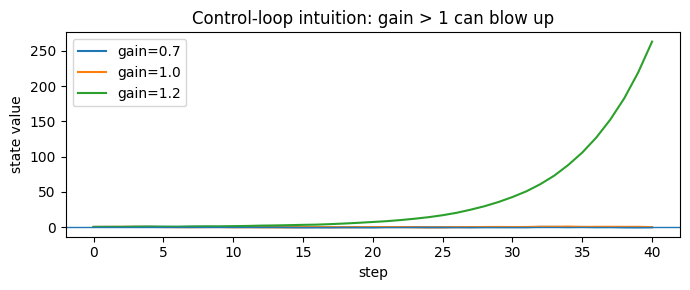

Agent translation: if each loop step reinforces a wrong guess, errors can grow instead of shrinking.


In [27]:
# @title Visual: a simple unstable loop (toy simulation)
# This is *not* an LLM simulation. It's a control-loop intuition demo.

def simulate_loop(steps=40, gain=1.2, noise=0.2):
    # State update: x_{t+1} = gain * x_t + noise_t
    # If gain > 1, small errors grow.
    x = 0.1
    xs = [x]
    for _ in range(steps):
        x = gain * x + np.random.normal(0, noise)
        xs.append(x)
    return xs

plt.figure(figsize=(7,3))
for g in [0.7, 1.0, 1.2]:
    xs = simulate_loop(gain=g)
    plt.plot(xs, label=f"gain={g}")
plt.axhline(0, linewidth=1)
plt.title("Control-loop intuition: gain > 1 can blow up")
plt.xlabel("step")
plt.ylabel("state value")
plt.legend()
plt.tight_layout()
plt.show()

print("Agent translation: if each loop step reinforces a wrong guess, errors can grow instead of shrinking.")


### Reflection
> In an agent loop, what’s the “gain”?  
> (Hint: anything that makes the agent more confident in a wrong belief.)

---

## **Unifying Diagram v5: add the agent loop**
We now have a course-wide diagram where:
- Retrieval (RAG) is a *tool*
- Calculator is a *tool*
- An agent loop chooses when to call them

We’ll add an outer loop around the system.


In [28]:
# @title Unifying Diagram v5 (Agent loop added)

mermaid = """
flowchart LR;
  U["User"] --> Q["Question"];
  Q --> PL["Agent policy / planner \n (choose next action)"];
  PL -->|"call tool"| T["Tools"];
  T -->|calculator| C["Calculator"];
  T -->|rag| R["RAG pipeline \n (retrieve -> context -> answer)"];
  C --> OBS["Observation"];
  R --> OBS;
  OBS --> ST["Update short-term state \n (notes/results)"];
  ST --> PL;
  PL -->|stop| OUT["Final response + tool trace"];
"""

from mermaid import Mermaid
display(Mermaid(mermaid))
# show_mermaid(mermaid)


---

# Day 1 wrap-up
- An **agent** is a **loop**, not a single call.
- Tools are **functions** (inputs → outputs), which makes behavior more checkable.
- Loops can become **unstable** without stop conditions and progress checks.
- Next class: we’ll build a **tool-choosing agent** (calculator vs RAG) and discuss determinism.

### Quick quiz preview
> **What makes an agent different from a single call?**  
Try to answer in one sentence.


---

# Day 2 — Tool selection only (no long-term memory yet)

## Today’s constraint (to reduce cognitive load)
Our agent will:
- **not** store long-term memory,
- **not** do multi-day planning,
- **only** decide *whether to call a tool*.

### Tools available today
- **Calculator** (for arithmetic)
- **RAG retrieval** (for “according to the docs…” questions)

---

## **What does “tool selection” mean?**
You can think of tool selection as a simple classification problem:

> Given a question, decide the next action:
- `CALL_CALCULATOR`
- `CALL_RAG`
- `ANSWER_DIRECTLY`

### Reflection
> Which of these decisions feels easiest? Which feels hardest?

---

## Deterministic vs stochastic behavior
When we debug an agent, we want:
- the same input → the same actions → the same outputs

That’s **determinism**.

But many agent policies include randomness:
- sampling from a model,
- tie-breaking among tools,
- temperature > 0.

That’s **stochasticity**.

**Engineering rule of thumb:**
- Develop and debug with **deterministic** settings.
- Add controlled randomness later (if you want exploration or creativity).

We’ll implement both: a deterministic tool policy and a “stochastic flip” version.


In [29]:
# @title A minimal tool-selection policy (deterministic + stochastic)
def looks_like_math(question: str) -> bool:
    # crude but effective for this course
    return bool(re.search(r"[0-9]", question)) and bool(re.search(r"[+\-*/%()]", question))

def looks_like_docs_question(question: str) -> bool:
    q = question.lower()
    triggers = ["according to", "policy", "runbook", "docs", "documentation", "what does it say", "source"]
    return any(t in q for t in triggers)

def choose_tool(question: str, p_flip: float = 0.0):
    # Base policy:
    #   - math-looking -> calculator
    #   - doc-looking  -> rag
    #   - else         -> none
    # Optional stochasticity: with probability p_flip, swap calculator<->rag (teaching instability).
    if looks_like_math(question):
        tool = "calculator"
    elif looks_like_docs_question(question):
        tool = "rag"
    else:
        tool = "none"

    if tool in ["calculator", "rag"] and random.random() < p_flip:
        tool = "rag" if tool == "calculator" else "calculator"

    return tool

tests = [
    "What is 17% of 84?",
    "According to the policy, can interns join on-call?",
    "Explain cosine similarity in one sentence.",
    "Compute (12+5)*3.",
    "What does the runbook say to do during an incident?"
]

for t in tests:
    print(choose_tool(t), "|", t)


calculator | What is 17% of 84?
rag | According to the policy, can interns join on-call?
none | Explain cosine similarity in one sentence.
calculator | Compute (12+5)*3.
rag | What does the runbook say to do during an incident?


### Reflection
> What kinds of questions might this policy misclassify?

---

## **From tool choice to an agent step**
Now we’ll wrap the tools into a *single-step agent*:

1) choose tool (or none)
2) call tool (if needed)
3) produce a response that includes a small “tool trace”

This is not a “full agent framework” — it’s the smallest agent loop you can build.


In [30]:
# @title One-step tool-choosing agent (calculator vs RAG)
def answer_directly(question: str):
    # Keep this simple: in real life, you'd call an LLM here.
    # For the lecture, we want students focused on *tool choice*.
    return "Direct answer (no tool). In Lab, you'll use an LLM for this step."

def agent_step(question: str, chunk_size=60, top_k=4, p_flip=0.0):
    tool = choose_tool(question, p_flip=p_flip)

    trace = []
    if tool == "calculator":
        trace.append("TOOL=calculator")
        # Extract a math expression (simple heuristic)
        expr = re.sub(r"[^0-9+\-*/().% ]", "", question)
        out = calculator(expr)
        if "error" in out:
            return {"tool": tool, "trace": trace, "answer": f"Calculator error: {out['error']}"}
        return {"tool": tool, "trace": trace, "answer": f"Result: {out['result']} (computed from '{expr.strip()}')"}
    elif tool == "rag":
        trace.append("TOOL=rag")
        ch = build_chunks(chunk_size=chunk_size, overlap=max(10, chunk_size//4))
        X_local = build_index(ch)
        out = rag_retrieve(question, ch, X_local, top_k=top_k)
        # A tiny, evidence-first response style:
        quote = out["passages"][0] if out["passages"] else "(no passages retrieved)"
        ans = "Based on the retrieved passage, here is the most relevant evidence:" + quote
        return {"tool": tool, "trace": trace, "answer": ans}
    else:
        trace.append("TOOL=none")
        return {"tool": tool, "trace": trace, "answer": answer_directly(question)}

# Try a few
examples = [
    "What is (12+5)*3?",
    "According to the policy, can interns join on-call?",
    "Explain what an agent is in one sentence."
]

for q in examples:
    out = agent_step(q, chunk_size=60, top_k=3, p_flip=0.0)
    print("\nQ:", q)
    print("tool:", out["tool"], "| trace:", out["trace"])
    print(out["answer"][:300], "...")



Q: What is (12+5)*3?
tool: calculator | trace: ['TOOL=calculator']
Result: 51 (computed from '(12+5)*3') ...

Q: According to the policy, can interns join on-call?
tool: rag | trace: ['TOOL=rag']
Based on the retrieved passage, here is the most relevant evidence:[policy_oncall::c0] the on call rotation is required for full time engineers and optional for interns interns may join on call only after completing onboarding and receiving manager approval interns should start with shadow shifts ...

Q: Explain what an agent is in one sentence.
tool: none | trace: ['TOOL=none']
Direct answer (no tool). In Lab, you'll use an LLM for this step. ...


---

## **Deterministic vs stochastic agent behavior (demo)**
Let’s see why randomness makes debugging hard.

We’ll run the *same question* multiple times:
- once with `p_flip=0.0` (deterministic)
- once with `p_flip=0.4` (stochastic)

### Reflection
> If you were grading a lab submission, would you want deterministic behavior? Why?


In [31]:
# @title Demo: same input, different behavior when stochastic
q = "According to the policy, can interns join on-call?"

print("Deterministic (p_flip=0.0):")
for _ in range(3):
    out = agent_step(q, p_flip=0.0)
    print(out["tool"], out["trace"])

print("\nStochastic (p_flip=0.4):")
for _ in range(8):
    out = agent_step(q, p_flip=0.4)
    print(out["tool"], out["trace"])


Deterministic (p_flip=0.0):
rag ['TOOL=rag']
rag ['TOOL=rag']
rag ['TOOL=rag']

Stochastic (p_flip=0.4):
calculator ['TOOL=calculator']
rag ['TOOL=rag']
rag ['TOOL=rag']
calculator ['TOOL=calculator']
rag ['TOOL=rag']
rag ['TOOL=rag']
calculator ['TOOL=calculator']
rag ['TOOL=rag']


---

# Part C — Quick evaluation: “Did we choose the right tool?”
In lab, you’ll build a simple tool-choosing agent.
So you need a way to test it.

We’ll create a tiny labeled set:
- math questions → calculator
- doc questions → RAG
- general questions → none

Then we’ll compute accuracy and inspect mistakes.

> This evaluation is intentionally simple — we’re practicing the habit of testing systems.


In [32]:
# @title Evaluate tool choice on a small labeled set
tool_eval = [
    {"q": "What is 17% of 84?", "gold": "calculator"},
    {"q": "Compute (12+5)*3.", "gold": "calculator"},
    {"q": "According to the policy, can interns join on-call?", "gold": "rag"},
    {"q": "What does the runbook say about incident response?", "gold": "rag"},
    {"q": "Explain in one sentence what an agent is.", "gold": "none"},
    {"q": "Write a short analogy for embeddings.", "gold": "none"},
]

def tool_accuracy(p_flip=0.0):
    correct = 0
    for ex in tool_eval:
        pred = choose_tool(ex["q"], p_flip=p_flip)
        correct += (pred == ex["gold"])
    return correct / len(tool_eval)

print("Accuracy (deterministic):", tool_accuracy(p_flip=0.0))
print("Accuracy (stochastic p_flip=0.3):", tool_accuracy(p_flip=0.3))

print("\nMistakes (deterministic):")
for ex in tool_eval:
    pred = choose_tool(ex["q"], p_flip=0.0)
    if pred != ex["gold"]:
        print("Q:", ex["q"])
        print("pred:", pred, "| gold:", ex["gold"])


Accuracy (deterministic): 1.0
Accuracy (stochastic p_flip=0.3): 0.6666666666666666

Mistakes (deterministic):


### Reflection
> If your agent chooses the wrong tool, how should it fail?
- Should it guess anyway?
- Should it ask a clarifying question?
- Should it try a second tool?
- Should it abstain (“I don’t know”)?

There is no single right answer — it depends on the product goal.

---

# Part D — Gradio demo: “Tool-Choosing Agent Playground”
This is a quick interactive demo for class:
- enter a question
- adjust chunk size and top-k (for RAG)
- adjust stochasticity (to see instability)
- inspect tool trace + retrieved passages



In [33]:
# @title Gradio demo

import gradio as gr

def playground(question, chunk_size, top_k, p_flip):
    out = agent_step(
        question,
        chunk_size=int(chunk_size),
        top_k=int(top_k),
        p_flip=float(p_flip)
    )
    tool = out["tool"]
    trace = " → ".join(out["trace"])
    return tool, trace, out["answer"]

demo = gr.Interface(
    fn=playground,
    inputs=[
        gr.Textbox(value="According to the policy, can interns join on-call?", label="Question"),
        gr.Slider(20, 140, value=60, step=5, label="Chunk size (words)"),
        gr.Slider(1, 10, value=4, step=1, label="top-k"),
        gr.Slider(0.0, 0.8, value=0.0, step=0.05, label="Stochastic flip probability (teaching only)")
    ],
    outputs=[
        gr.Textbox(label="Chosen tool"),
        gr.Textbox(label="Tool trace"),
        gr.Textbox(label="Output / answer")
    ],
    title="Week 6: Tool-Choosing Agent Playground (minimal)",
    description="This demo focuses on tool selection, not long-term memory or multi-step planning."
)

demo.launch(debug=False, share=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

---

# Lab  (in-class start): Simple Tool-Choosing Agent
Today you’ll start the next lab in class.

## Lab goal
Build a simple agent that decides **when to call calculator or RAG**.

### Minimum requirements
- If the question is arithmetic: call **Calculator**
- If the question asks “according to policy/docs/runbook”: call **RAG**
- Otherwise: answer directly (or abstain)
- Log:
  - chosen tool
  - a short reason (1 sentence)
  - tool inputs/outputs (for debugging)

### Suggested stretch goals
- Add a **two-step fallback**:
  - if you answered directly but confidence is low → try RAG
- Add a **stop condition**:
  - maximum 2 tool calls
- Add a **safety check**:
  - if calculator expression is empty → ask user to rephrase

---

## Quiz (end of week): “What makes an agent different from a single call?”
Try answering now:

> **In one sentence:** what makes an agent different from a single LLM call?

### Target answer ingredients (any 3–4 are great)
- multiple steps / loop
- tool calls with observations
- state (short-term memory) updated over time
- policy for choosing actions
- stopping rule / budget


---

<details>
<summary><strong>Instructor Notes</strong> (click to expand)</summary>

### Tue 6 pacing (50 min)
- **0–10** Lab D review (chunking & hallucinations). Ask for “knob → effect → tradeoff.”
- **10–18** Motivation: inspiring agent success + fun failure (retry spiral).
- **18–28** Teach plan–act–observe with the loop diagram. Emphasize “system, not model.”
- **28–38** Tools as function calls. Show calculator + RAG as two examples.
- **38–46** Instability: retry spirals, ping-pong, feedback amplification. Show toy gain plot.
- **46–50** Unifying Diagram v5 + quiz preview.

### Thu 6 pacing (50 min)
- **0–8** Recap + scope constraint (“tool selection only today”).
- **8–18** Tool selection as classification. Do quick “Calculator/RAG/None” hand-raise activity.
- **18–30** Deterministic vs stochastic. Run the p_flip demo and ask why debugging becomes hard.
- **30–40** Show minimal agent step (choose tool → call tool → return trace).
- **40–50** Start Lab I in class. Students pick 6–10 test questions and label which tool should be used.

### Slide cues
- “Agent = control loop” diagram (Plan–Act–Observe)
- “Tools are functions” (input JSON → output JSON)
- “Why loops become unstable” (retry spiral, ping-pong, amplification)
- Unifying Diagram v5 (outer agent loop around tools)

### Discussion transitions (useful phrases)
- “Notice we didn’t add intelligence — we added *iteration*.”
- “A tool call is a testable step. That’s why agents can be more reliable.”
- “If you can’t tell when to stop, the loop will invent work.”

### Optional extensions (advanced)
- Add a progress check (“Did we learn something new this step?”)
- Add a second tool (e.g., “search docs” vs “retrieve passages”)
- Add a simple confidence score to trigger RAG fallback

</details>
